## 主成分分析によるデータ圧縮

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import common

import numpy as np

import pandas as pd

cols = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

df_wine = pd.read_csv("data/wine.data",names=cols,header=None)

y, x = df_wine["Class label"], df_wine.iloc[:,1:]
x_train, x_test, y_train, y_test = train_test_split(x.values,y.values, test_size=0.3, random_state=0, stratify=y)

from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

##### 主成分分析: 手順

1. d次元のデータセットを標準化する
2. 標準化したデータセットの共分散行列を生成する
3. 共分散行列を固有値、固有ベクトルに訓戒する。
4. 固有値を降順でソートすることで、対応する固有ベクトルをランク付けする。
5. 最も大きいkこの固有値に対応するkこの固有ベクトルを選択する。
6. 上位kこの固有ベクトルから射影行列wを生成する。
7. 射影行列Wを使って、d次元の入力データセットを変換し、新しいk次元の特徴量部分空間を取得する

共分散行列(covariance matrix)
$
Cov = \frac{1}{n}\sum_{i=1}^n
\left(x^{(i)}_j-\mu_j\right)
\left(x^{(i)}_k-\mu_k\right)
$


分散説明率(variance explained ratio)
$\eta_j = \frac{\lambda_j}{\sum_{j=1}^{d}\lambda_j}$


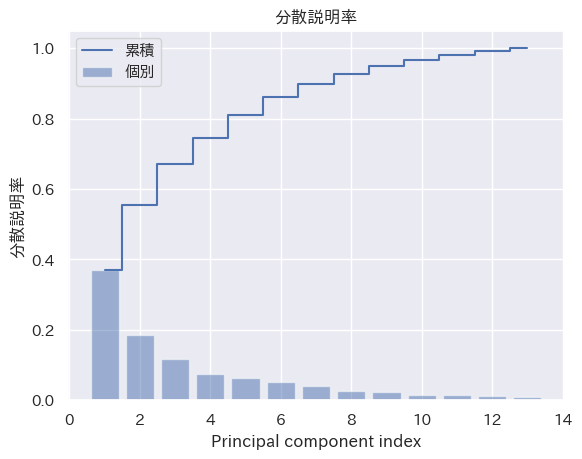

In [21]:
cov_mat = np.cov(x_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(1, 14), var_exp, alpha=0.5, align='center',label='個別')
plt.step(range(1, 14), cum_var_exp, where='mid',label='累積')
plt.title("分散説明率");plt.ylabel('分散説明率');plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

#### 特徴量変換

In [22]:
eigen_pairs = [(np.abs(eig), eigen_vecs[:,idx]) for idx, eig in enumerate(eigen_vals)]
eigen_pairs = sorted(eigen_pairs, key=lambda k:k[0], reverse=True)
ev0=eigen_pairs[0][1]
ev1= eigen_pairs[1][1]
w = np.array([ev0,ev1]).T

#### 変換後の特徴量

共分散行列(サイズ$d \times d$)より、固有値の大きい順に上位$k$個を選択してその固有ベクトルを選択したものを

射影行列(サイズ$d \times k$)といい、特徴量は下記のように変換される($x\rightarrow x'$)

$
x' = xW
$

変換ごとの特徴量($k=2$の場合)をプロットしたものを下記に示す

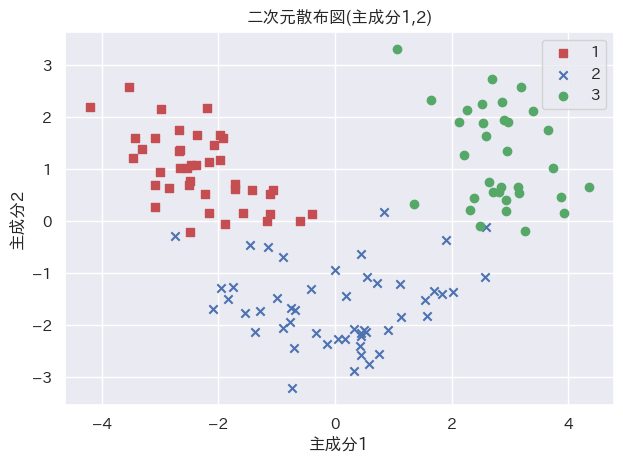

In [23]:
x_train_std.dot(w).shape
X_train_pca = x_train_std.dot(w)
colors = ['r', 'b', 'g'];markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y_train), colors, markers):
  plt.scatter(
    X_train_pca[y_train == l, 0], 
    X_train_pca[y_train == l, 1], 
    c=c, label=l, marker=m
  )

plt.title("二次元散布図(主成分1,2)")
plt.xlabel('主成分1');plt.ylabel('主成分2');plt.legend(loc='best')
plt.tight_layout()
plt.show()

5.1.5 scikit-learnの主成分分析

/home/yuta/ML/common.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


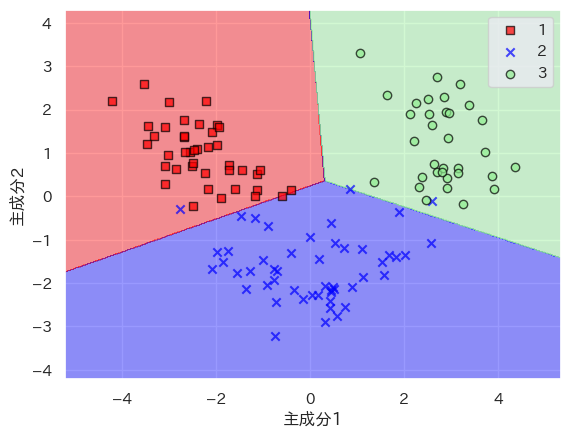

In [24]:
#NOTE: 主成分数を指定してPCAインスタンスを生成。
pca = PCA(n_components=2)

#NOTE: 次元削減(特徴量抽出)
x_train_pca = pca.fit_transform(x_train_std)
x_test_pca = pca.transform(x_test_std)


#NOTE* 路地串ティック快気のインスタンすを生成
lr = LogisticRegression(multi_class="ovr", random_state = 1, solver = 'lbfgs')

# NOTE: 次元削減後の特徴量に対し、lrを適合させる
lr.fit(x_train_pca, y_train)

common.plot_decision_regions(x_train_pca, y_train, classifier=lr)



#### *線形判別分析による教師ありデータ圧縮*

クラスの分離を最適化する特徴量部分空間を見つけ出そうとする

##### 前提条件
- データが正規分布に従うこと
- クラスのよう分散行列が同一であること
- 訓練データが統計学的に見て互いに独立している。

<img src="ch05/images/05_06.png" width=50%>

- -:  クラス1
- +:  クラス2


#### LDAの手順
1. d次元のデータセットを標準化する(d: 特徴量の個数)
2. クラスごとにd次元の平均ベクトル(各次元の平均値で構成されるベクトル)を計算する
3. 平均ベクトルを使ってクラス間変動行列$S_B$と、クラス内変動行列$S_w$を生成する
4. 行列$S^{-1}_WS_{B}$の固有ベクトルと対応する固有値を計算する
5. 固有値を降順でソートすることで対応する固有ベクトルをランク付けする。
6. dxk次元の変換行列$W$を生成するために、最も大きい$k$この固有値に対応する$k$この固有ベクトルを選択する。
7. 変換行列$W$を使ってデータ店を新しい特徴量部分空間へ射影する。

##### クラス内変動行列

$
S_W = \sum_{i\in class} S_i,
$

$
S_i = \sum_{x\in D_i} \left(x-m_i\right)^T\left(x-m_i\right) 
$

平均ベクトル: クラスiに属するデータに関する平均特徴量

$
m_i = \frac{1}{n_i}\sum_{x\in D_i}\mathbf{x}
$

##### 目的1: 別クラスのデータをできるだけ遠くへ離す

射影の後、クラスが異なるデータサンプルができるだけ離れるようにしたい。
→ 各クラスのサンプル平均が、全サンプル平均から離れていれば良い
各クラスのサンプル平均と全サンプル平均との間で、射影後の差分の平方和


##### 目的2: 同じクラスのデータをできるだけ近くに固める
射影の後、クラスが同じデータサンプルはできるだけ近くに固まるようにしたい。
→各データサンプルと、属するクラスのサンプル平均との間で、射影後の差分の平方和を最小化したい。

→目的1 / 目的2 の最大化。　これをLagranguの未定乗数法により求解すると、

$$
S^{-1}_WS_{B}
$$

の固有値問題に帰着される

##### クラス間変動行列
$$
S_B
\equiv \displaystyle \sum_{C} n_C \left( \boldsymbol{m}_C - \boldsymbol{m} \right) \left( \boldsymbol{m}_C - \boldsymbol{m} \right)^T \\
= \begin{pmatrix}
\displaystyle \sum_{C} n_C \left(m_{C,1} - m_1 \right) \left(m_{C,1} - m_1 \right)  \cdots  \displaystyle \sum_{C} n_C \left(m_{C,1} - m_1 \right) \left(m_{C,d} - m_d \right) \\
\vdots    \vdots \\
\displaystyle \sum_{C} n_C \left(m_{C,d} - m_d \right) \left(m_{C,1} - m_1 \right)  \cdots  \displaystyle \sum_{C} n_C \left(m_{C,d} - m_d \right) \left(m_{C,d} - m_d \right)
\end{pmatrix}
$$

##### クラス内変動行列

$$
S_W
\equiv \displaystyle \sum_{C} \sum_{\boldsymbol{x}^{(i)} \in C} \left( \boldsymbol{x}^{(i)} - \boldsymbol{m}_C \right) \left( \boldsymbol{x}^{(i)} - \boldsymbol{m}_C \right)^T \\
= \begin{pmatrix}
\displaystyle \sum_{C} \sum_{\boldsymbol{x}^{(i)} \in C} \left( x_1^{(i)} - m_{C,1} \right) \left( x_1^{(i)} - m_{C,1} \right)  \cdots  \displaystyle \sum_{C} \sum_{\boldsymbol{x}^{(i)} \in C} \left( x_1^{(i)} - m_{C,1} \right) \left( x_d^{(i)} - m_{C,d} \right) \\
\vdots    \vdots \\
\displaystyle \sum_{C} \sum_{\boldsymbol{x}^{(i)} \in C} \left( x_d^{(i)} - m_{C,d} \right) \left( x_1^{(i)} - m_{C,1} \right)  \cdots  \displaystyle \sum_{C} \sum_{\boldsymbol{x}^{(i)} \in C} \left( x_d^{(i)} - m_{C,d} \right) \left( x_d^{(i)} - m_{C,d} \right)
\end{pmatrix}
$$

クラス内:データサンプル平均
$$
\boldsymbol{m}_C \equiv \displaystyle \cfrac{1}{n_C} \sum_{\boldsymbol{x}^{(i)} \in C} \boldsymbol{x}^{(i)}
$$

全クラス:データサンプル平均
$$
\boldsymbol{m} \equiv \displaystyle \cfrac{1}{n} \sum_{i=1}^{n} \boldsymbol{x}^{(i)}
$$


In [25]:
np.set_printoptions(precision=4)
 
mean_vecs = [
  np.mean(x_train_std[y_train == l], axis=0)
  for l in np.unique(y_train)
]


d = 13 # number of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d, d))  # scatter matrix for each class
    for row in x_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)  # make column vectors
        class_scatter += (row - mv).dot((row - mv).T)
    S_W += class_scatter                          # sum class scatter matrices

print('Within-class scatter matrix: %sx%s' % (S_W.shape[0], S_W.shape[1]))

Within-class scatter matrix: 13x13


In [26]:
print('Class label distribution: %s'%np.bincount(y_train)[1:])

Class label distribution: [41 50 33]


In [27]:
d = 13  # number of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(x_train_std[y_train == label].T)
    S_W += class_scatter
print('Scaled within-class scatter matrix: %sx%s' % (S_W.shape[0],S_W.shape[1]))

Scaled within-class scatter matrix: 13x13


##### 5.2.4 新しい特徴量部分空間の線形判別を選択

$S^{-1}_WS_{B}$の固有値問題を解く。

In [28]:
mean_overall = np.mean(x_train_std, axis=0)
d = 13  # number of features
S_B = np.zeros((d, d))
for i, mean_vec in enumerate(mean_vecs):
    n = x_train_std[y_train == i + 1, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1)  # make column vector
    mean_overall = mean_overall.reshape(d, 1)  # make column vector
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

print('Between-class scatter matrix: %sx%s' % (S_B.shape[0], S_B.shape[1]))

Between-class scatter matrix: 13x13


In [29]:
# eig: 固有値、固有ベクトル計算
# inv: 逆行列
# dot: 行列の積
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues

print('Eigenvalues in descending order:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Eigenvalues in descending order:

349.61780890599397
172.76152218979385
8.083700457542382e-14
3.5021010787077537e-14
2.55913878694663e-14
2.55913878694663e-14
1.1800646330824407e-14
9.54558150994035e-15
9.465678066411808e-15
9.465678066411808e-15
5.830160026378068e-15
3.71723684807219e-15
1.788037173519217e-15


##### 判別性評価
線形判別によって、クラスの判別情報がどの程度補足されるのか可視化

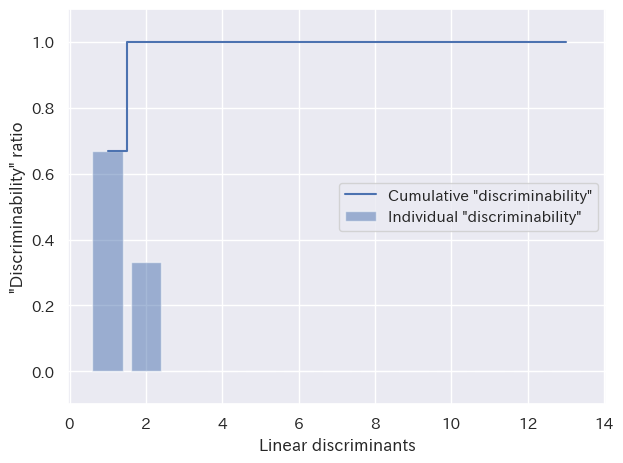

In [30]:
tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)

plt.bar(range(1, 14), discr, alpha=0.5, align='center',
        label='Individual "discriminability"')
plt.step(range(1, 14), cum_discr, where='mid',
         label='Cumulative "discriminability"')
plt.ylabel('"Discriminability" ratio')
plt.xlabel('Linear discriminants')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig('images/05_07.png', dpi=300)
plt.show()

In [31]:
eigen_pairs = [(np.abs(eig).real, eigen_vecs[:,idx].real) for idx, eig in enumerate(eigen_vals.real)]
eigen_pairs = sorted(eigen_pairs, key=lambda k:k[0], reverse=True)
ev0=eigen_pairs[0][1]
ev1= eigen_pairs[1][1]
w = np.array([ev0,ev1]).T

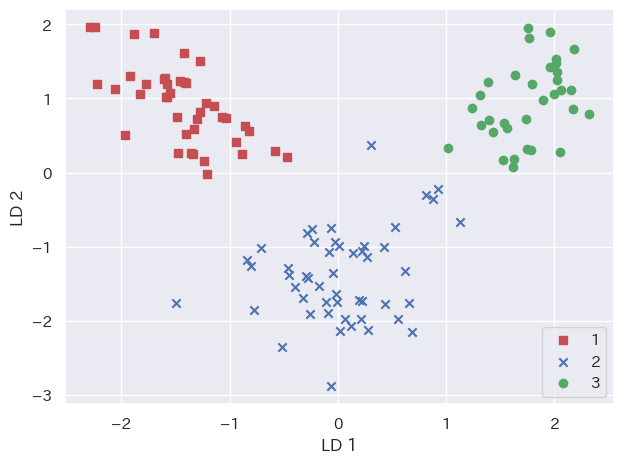

In [32]:
X_train_lda = x_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == l, 0],
                X_train_lda[y_train == l, 1] * (-1),
                c=c, label=l, marker=m)

plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('images/05_08.png', dpi=300)
plt.show()

##### scikit-learnによる線形判別分析

/home/yuta/ML/common.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


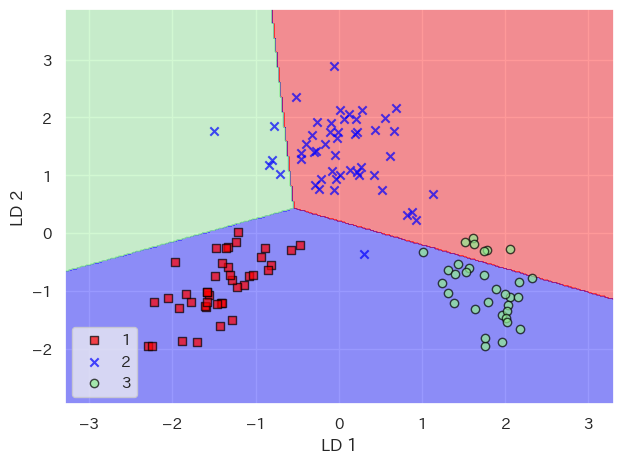

In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)

x_train_lda = lda.fit_transform(x_train_std, y_train)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs')
lr = lr.fit(x_train_lda, y_train)
common.plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

/home/yuta/ML/common.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


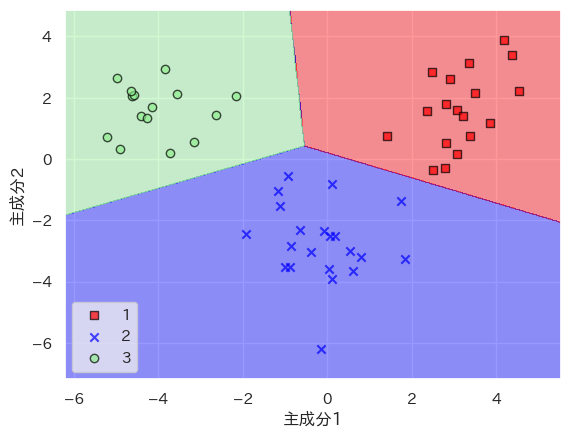

In [34]:
X_test_lda = lda.transform(x_test_std)

common.plot_decision_regions(X_test_lda, y_test, classifier=lr)
# # plt.xlabel('LD 1')
# # plt.ylabel('LD 2')
# plt.legend(loc='lower left')
# plt.tight_layout()
# # plt.savefig('images/05_10.png', dpi=300)
plt.show()

#### KernelPCA
pythonによるカーネル主成分分析

In [35]:
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh
import numpy as np


from numpy import exp

def rbf_kernel_pca(X, gamma, n_components):
    """
    RBF kernel PCA implementation.

    Parameters
    ------------
    X: {NumPy ndarray}, shape = [n_examples, n_features]
        
    gamma: float
      Tuning parameter of the RBF kernel
        
    n_components: int
      Number of principal components to return

    Returns
    ------------
     X_pc: {NumPy ndarray}, shape = [n_examples, k_features]
       Projected dataset   

    """
    # データセット間のペアごとのユークリッド距離二乗を算出
    # データ点数Nとすると、nC2 = N*(N-1)/2このデータを出力
    
    sq_dists = pdist(X, 'sqeuclidean')

    # 距離行列(N*N)形式に変換
    mat_sq_dists = squareform(sq_dists)

    # Compute the symmetric kernel matrix.
    K = exp(-gamma * mat_sq_dists)

    # 中心化
    N = K.shape[0]
    one_n = np.ones((N, N)) / N
    K = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)

    # Obtaining eigenpairs from the centered kernel matrix
    # scipy.linalg.eigh returns them in ascending order
    eigvals, eigvecs = eigh(K)
    eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]

    # Collect the top k eigenvectors (projected examples)
    X_pc = np.column_stack([eigvecs[:, i]
                            for i in range(n_components)])

    return X_pc

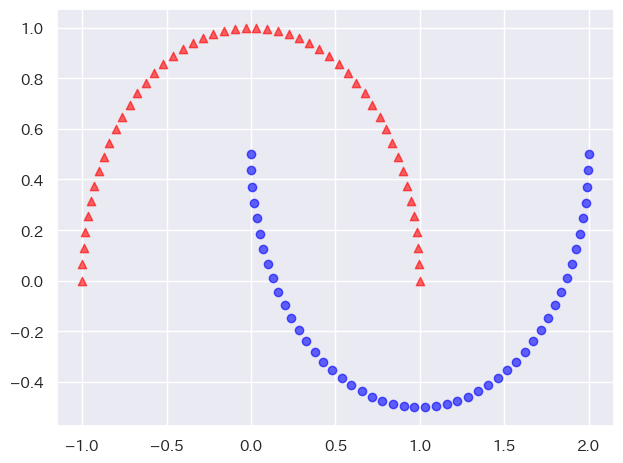

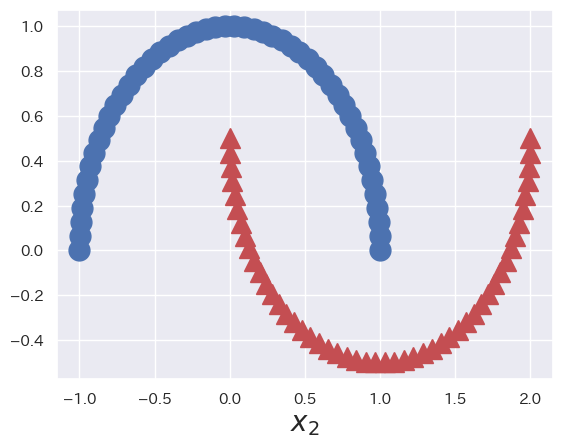

In [60]:
from sklearn.datasets import make_moons

X,y = make_moons(n_samples = 100, random_state=3)

# X: [100,2], y = [100,1]
plt.scatter(X[y==0,0], X[y==0, 1], color = "red", marker="^", alpha = 0.6)
plt.scatter(X[y==1,0], X[y==1, 1], color = "blue", marker="o", alpha = 0.6)

plt.tight_layout()
plt.show()

import common

common.plot_dataset(X,y)


標準PCA

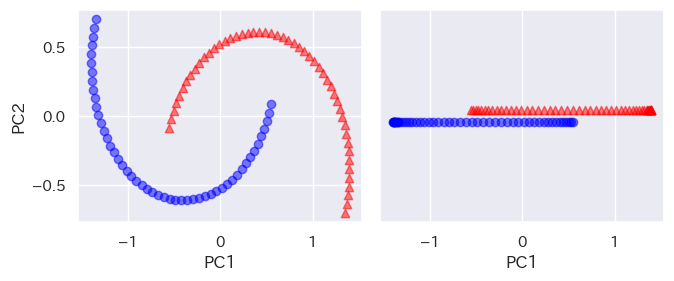

In [37]:
from sklearn.decomposition import PCA

scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

ax[0].scatter(X_spca[y == 0, 0], X_spca[y == 0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y == 1, 0], X_spca[y == 1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y == 0, 0], np.zeros((50, 1)) + 0.06,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y == 1, 0], np.zeros((50, 1)) - 0.06,
              color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
# plt.savefig('images/05_13.png', dpi=300)
plt.show()

左図: 主成分1,2でプロット

右図: 次元削減(主成分1のみでプロット)→　プロット領域が重なり→線形分離できていない 

KernelPCA: $\gamma$値別

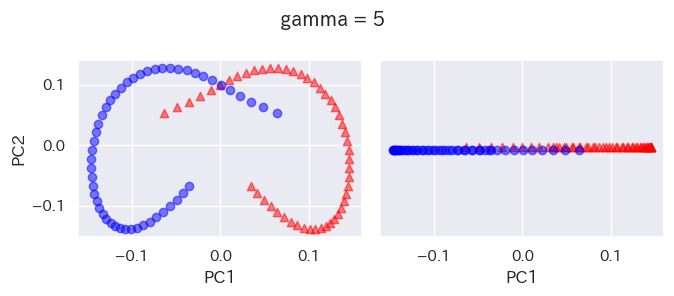

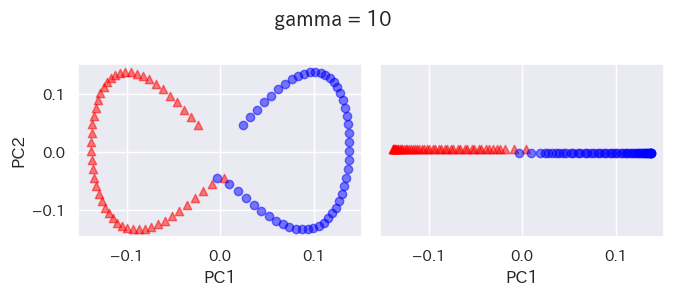

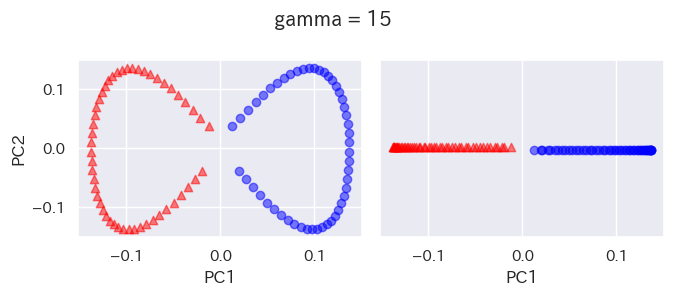

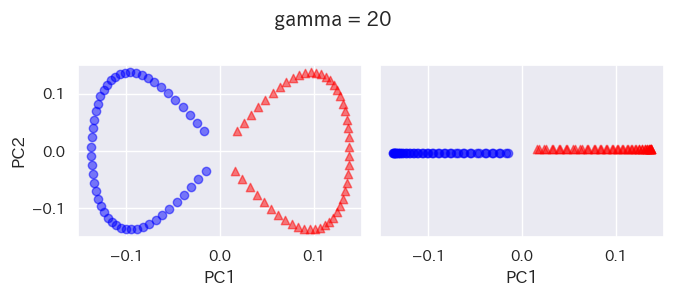

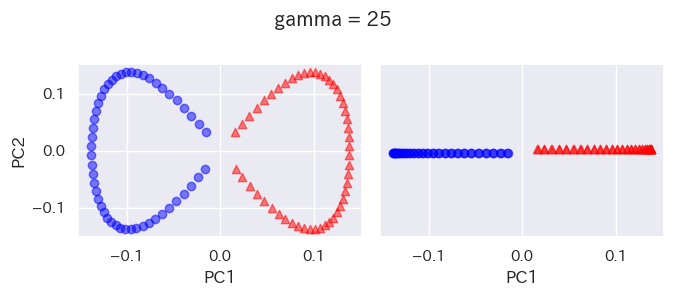

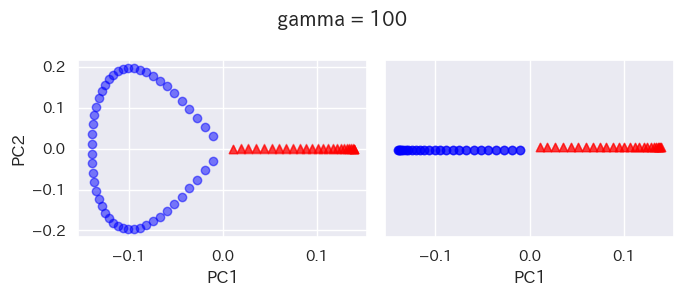

In [38]:
for g in [5,10,15,20,25,100]:

  X_kpca = rbf_kernel_pca(X, gamma=g, n_components=2)

  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))
  fig.suptitle("gamma = %d"%g)
  ax[0].scatter(X_kpca[y==0, 0], X_kpca[y==0, 1], 
            color='red', marker='^', alpha=0.5)
  ax[0].scatter(X_kpca[y==1, 0], X_kpca[y==1, 1],
            color='blue', marker='o', alpha=0.5)

  ax[1].scatter(X_kpca[y==0, 0], np.zeros((50, 1))+0.02, 
            color='red', marker='^', alpha=0.5)
  ax[1].scatter(X_kpca[y==1, 0], np.zeros((50, 1))-0.02,
            color='blue', marker='o', alpha=0.5)

  ax[0].set_xlabel('PC1')
  ax[0].set_ylabel('PC2')
  ax[1].set_ylim([-1, 1])
  ax[1].set_yticks([])
  ax[1].set_xlabel('PC1')

  plt.tight_layout()
  # plt.savefig('images/05_14.png', dpi=300)
  plt.show()

例2: 同心円の分離

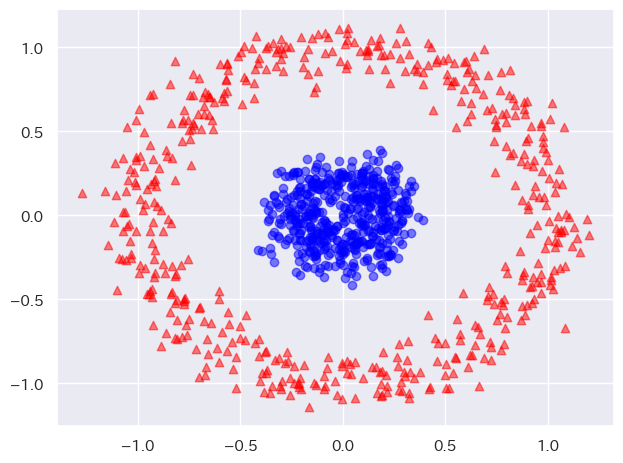

In [44]:
#NOTE: データセットの読み込み、プロット
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 1000, random_state = 123, noise = 0.1, factor = 0.2)

plt.scatter(X[y==0, 0],X[y==0, 1], color = "red", marker = '^', alpha=0.5)
plt.scatter(X[y==1, 0],X[y==1, 1], color = "blue", marker = 'o', alpha=0.5)
plt.tight_layout()
plt.show()

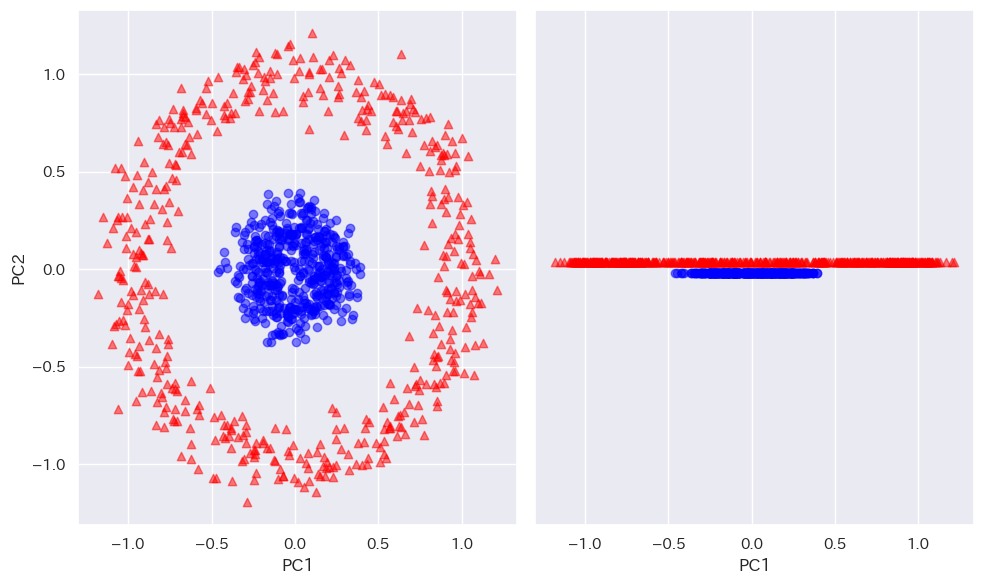

In [46]:
#NOTE: データをPCAで変換してからプロット
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

ax[0].scatter(X_spca[y == 0, 0], X_spca[y == 0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y == 1, 0], X_spca[y == 1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y == 0, 0], np.zeros((500, 1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y == 1, 0], np.zeros((500, 1)) - 0.02,
              color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')

plt.tight_layout()
plt.show()

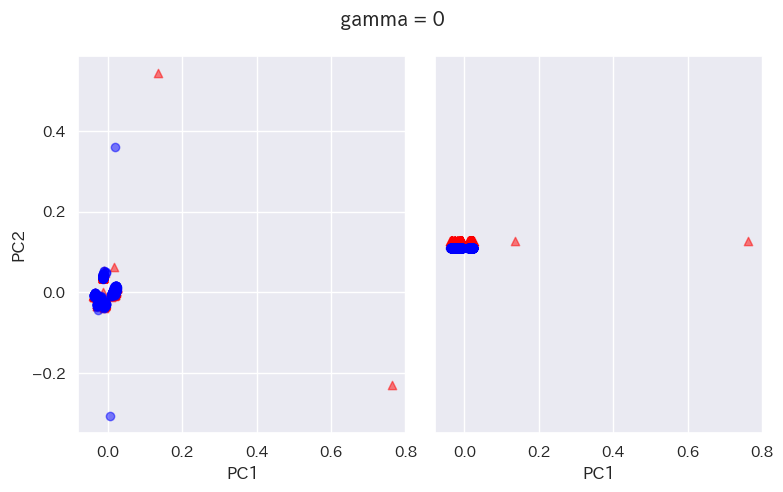

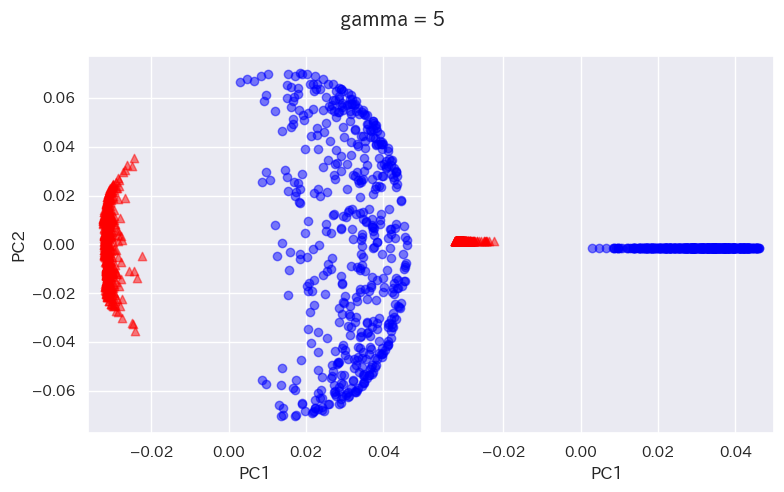

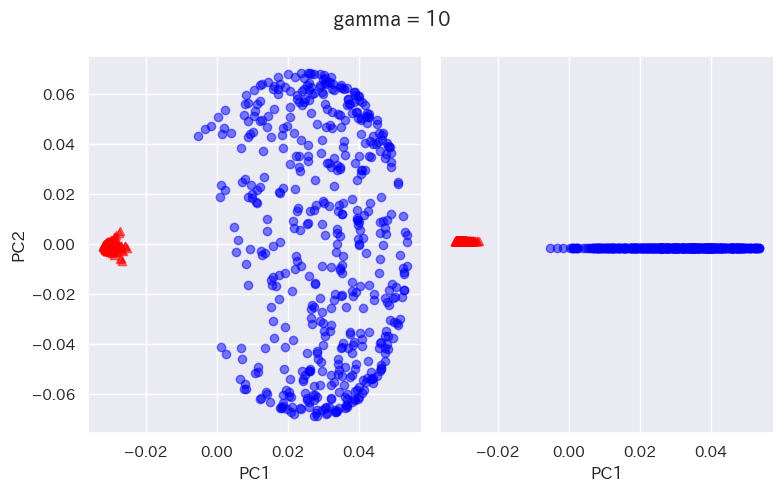

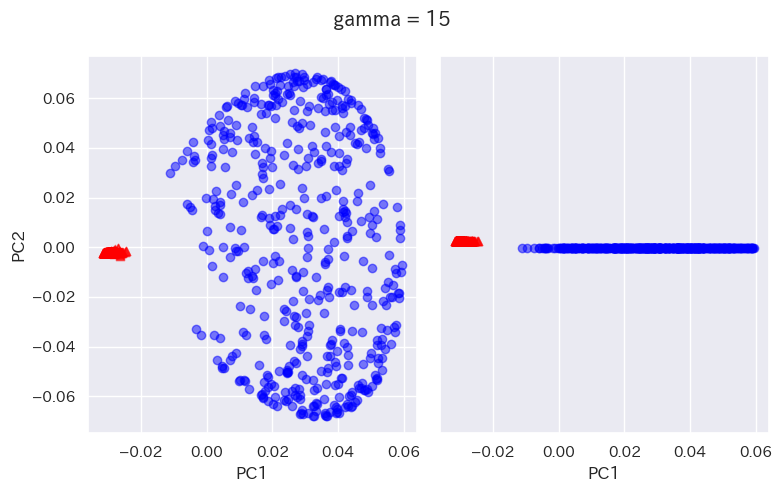

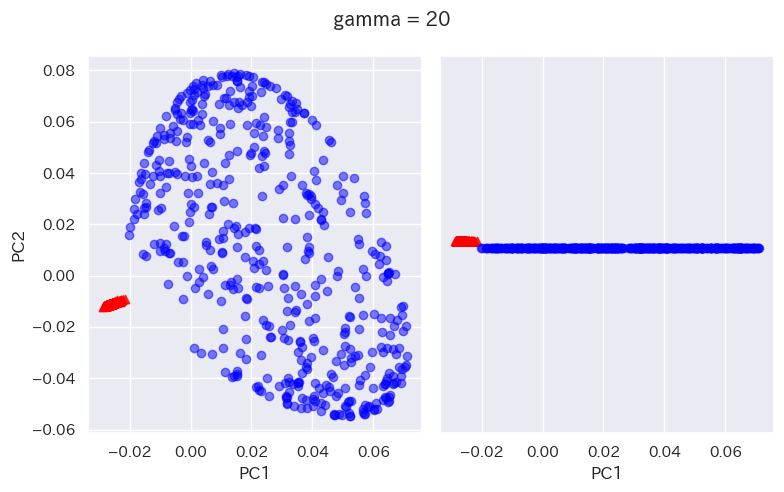

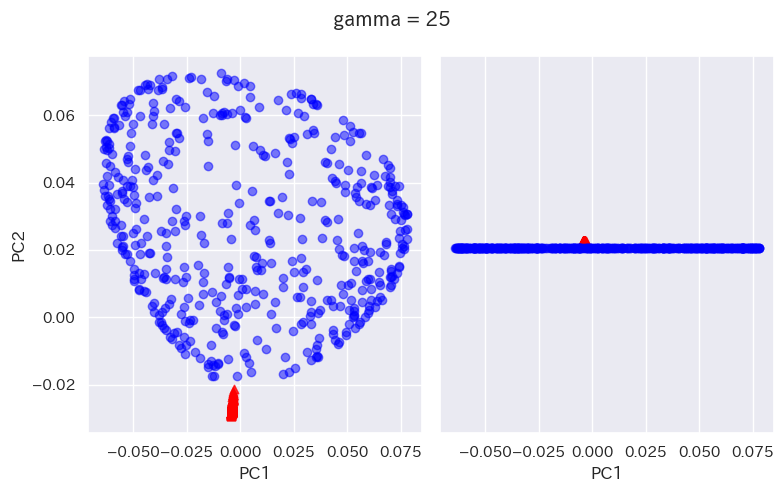

In [49]:
# Kernel PCA ガンマ値別
for g in [0,5,10,15,20,25]:

  X_kpca = rbf_kernel_pca(X, gamma=g, n_components=2)

  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
  fig.suptitle("gamma = %d"%g)
  ax[0].scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1],
                color='red', marker='^', alpha=0.5)
  ax[0].scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1],
                color='blue', marker='o', alpha=0.5)

  ax[1].scatter(X_kpca[y == 0, 0], np.zeros((500, 1)) + 0.02,
                color='red', marker='^', alpha=0.5)
  ax[1].scatter(X_kpca[y == 1, 0], np.zeros((500, 1)) - 0.02,
                color='blue', marker='o', alpha=0.5)

  ax[0].set_xlabel('PC1')
  ax[0].set_ylabel('PC2')
  ax[1].set_ylim([-1, 1])
  ax[1].set_yticks([])
  ax[1].set_xlabel('PC1')

  plt.tight_layout()
  # plt.savefig('images/05_17.png', dpi=300)
  plt.show()

#5.3.3 新しいデータ店の射影

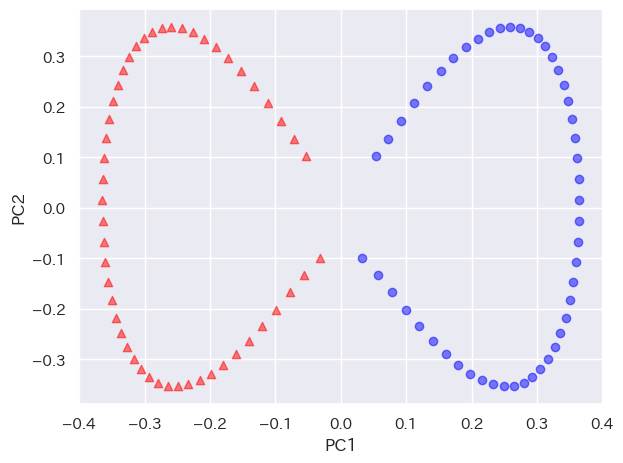

In [50]:
from sklearn.decomposition import KernelPCA

X, y = make_moons(n_samples=100, random_state=123)
scikit_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_skernpca = scikit_kpca.fit_transform(X)

plt.scatter(X_skernpca[y == 0, 0], X_skernpca[y == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_skernpca[y == 1, 0], X_skernpca[y == 1, 1],
            color='blue', marker='o', alpha=0.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
# plt.savefig('images/05_19.png', dpi=300)
plt.show()

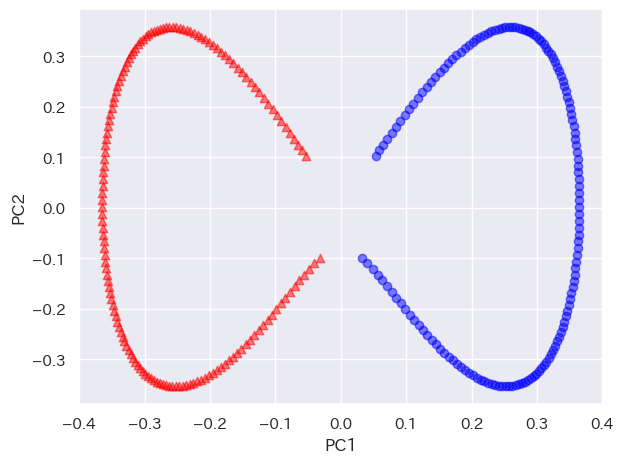

In [56]:
X_test, y_test = make_moons(n_samples=300, random_state=2)


X_pca = scikit_kpca.transform(X_test)

plt.scatter(X_pca[y_test == 0, 0], X_pca[y_test == 0, 1],
            color='red', marker='^', alpha=0.5)
plt.scatter(X_pca[y_test == 1, 0], X_pca[y_test == 1, 1],
            color='blue', marker='o', alpha=0.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
# plt.savefig('images/05_19.png', dpi=300)
plt.show()

In [52]:
X_pca

array([[ 0.3591, -0.117 ],
       [-0.3613,  0.1071],
       [-0.3591, -0.117 ],
       [ 0.2576,  0.3578],
       [-0.1614,  0.282 ],
       [-0.2576,  0.3578],
       [ 0.0531,  0.1028],
       [ 0.2478, -0.3537],
       [-0.0323, -0.0999],
       [ 0.3613,  0.1071],
       [ 0.3266,  0.2904],
       [-0.0531,  0.1028],
       [ 0.1492, -0.2758],
       [ 0.0323, -0.0999],
       [-0.3202, -0.2929],
       [-0.1492, -0.2758],
       [-0.3266,  0.2904],
       [ 0.1614,  0.282 ],
       [-0.2478, -0.3537],
       [ 0.3202, -0.2929]])

In [53]:
y_test

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1])